In [ ]:
# Counter warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Importing libraries
import numpy as np
import pandas as pd

# Importing visualization libraries
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [4]:
# Reading data
data = pd.read_csv('data.csv')

### Step 1: Read and explore data

In [6]:
# ID: row identifier
# Warehouse_block: Warehousing block/section
# Model_of_Shipment: Shipment mode flight/road/boat
# Customer_care_calls: Number of calls made to customer care
# Customer_rating: Rating given by customer
# Cost_of_the_product: Product cost
# Prior_purchases: Number of products purchased by customer before
# Product_importance: Product criticality
# Gender: Customer's gender
# Discount_offered: Discount availed by the customer
# Weight_in_gms: Weight of product in grams
# Reached.on.Time_Y.N: Dependent variable

In [7]:
data.head()

,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177.0,3,low,F,44,1233.0,1
1,2,F,Flight,4,5,216.0,2,low,M,59,3088.0,1
2,3,A,Flight,2,2,183.0,4,low,M,48,3374.0,1
3,4,B,Flight,3,3,176.0,4,medium,M,10,1177.0,1
4,5,C,Flight,2,2,184.0,3,medium,F,46,2484.0,1


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10999 non-null  int64  
 1   Warehouse_block      10999 non-null  object 
 2   Mode_of_Shipment     10999 non-null  object 
 3   Customer_care_calls  10999 non-null  int64  
 4   Customer_rating      10999 non-null  int64  
 5   Cost_of_the_Product  10901 non-null  float64
 6   Prior_purchases      10999 non-null  int64  
 7   Product_importance   10845 non-null  object 
 8   Gender               10999 non-null  object 
 9   Discount_offered     10999 non-null  int64  
 10  Weight_in_gms        10860 non-null  float64
 11  Reached.on.Time_Y.N  10999 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 1.0+ MB


In [12]:
for column in data.columns:
    print(f"Column name: {column}")
    print(f"Unique values: {data[column].unique()}\n")

Column name: ID
Unique values: [    1     2     3 ... 10997 10998 10999]

Column name: Warehouse_block
Unique values: ['D' 'F' 'A' 'B' 'C']

Column name: Mode_of_Shipment
Unique values: ['Flight' 'Ship' 'Road']

Column name: Customer_care_calls
Unique values: [4 2 3 5 6 7]

Column name: Customer_rating
Unique values: [2 5 3 1 4]

Column name: Cost_of_the_Product
Unique values: [177. 216. 183. 176. 184. 162. 250. 233. 150. 164. 189. 232. 198. 275.
 152. 227. 143. 239. 145. 161. 156. 211. 251. 225. 172.  nan 223. 234.
 149. 137. 181. 215. 269. 139. 174. 151. 210. 169. 160. 190. 141. 165.
 170. 203. 246. 238. 193. 221. 179. 105. 261. 202. 109. 158. 231. 206.
 187. 230. 266. 113. 257. 180. 132. 286. 175. 219. 213. 235. 271. 144.
 218. 263. 168. 265. 205. 252. 222. 220. 147. 200. 224. 247. 280. 157.
 207. 237. 264. 248. 191. 146. 135.  98.  97. 114. 112. 274. 166. 185.
 148. 270. 192. 116. 255. 209. 134. 130. 133. 140. 136. 142. 154. 155.
 127. 129. 242. 159. 294. 226. 258. 241. 208. 182. 2

### Step 2: Missing value imputation

Cost_of_the_Product</br>
Product_importance</br>
Weight_in_gms

In [15]:
data.isna().sum()

ID                       0
Warehouse_block          0
Mode_of_Shipment         0
Customer_care_calls      0
Customer_rating          0
Cost_of_the_Product     98
Prior_purchases          0
Product_importance     154
Gender                   0
Discount_offered         0
Weight_in_gms          139
Reached.on.Time_Y.N      0
dtype: int64

Cost_of_the_Product

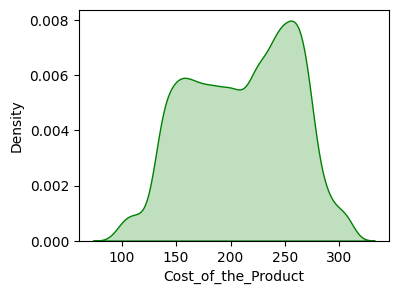

In [26]:
fig = plt.figure(figsize=(4, 3))
sns.kdeplot(data.Cost_of_the_Product, fill=True, color='green')
plt.show()

In [27]:
mean_cost = data.Cost_of_the_Product.mean()
median_cost = data.Cost_of_the_Product.median()

print('left skewed' if mean_cost < median_cost else 'right skewed' if mean_cost > median_cost else 'normal')

left skewed


In [28]:
# replacing null values with median
data.Cost_of_the_Product.fillna(median_cost, inplace=True)

Product_importance

In [37]:
data.Product_importance.value_counts()

Product_importance
low       5217
medium    4698
high       930
Name: count, dtype: int64

In [38]:
data.Product_importance.fillna('low', inplace=True)

Weight_in_gms

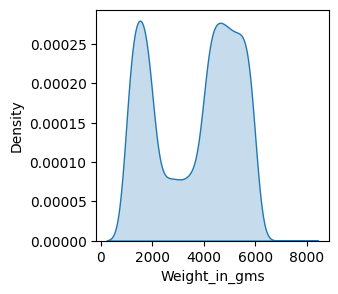

In [41]:
fig = plt.figure(figsize=(3,3))
sns.kdeplot(data.Weight_in_gms, fill=True)
plt.show()

In [43]:
mean_weight = data.Weight_in_gms.mean()
median_weight = data.Weight_in_gms.median()
print('left skewed' if mean_weight < median_weight else 'right skewed' if mean_weight > median_weight else 'normal')

left skewed


In [44]:
# Replacing with median
data.Weight_in_gms.fillna(median_weight, inplace=True)

In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   10999 non-null  int64  
 1   Warehouse_block      10999 non-null  object 
 2   Mode_of_Shipment     10999 non-null  object 
 3   Customer_care_calls  10999 non-null  int64  
 4   Customer_rating      10999 non-null  int64  
 5   Cost_of_the_Product  10999 non-null  float64
 6   Prior_purchases      10999 non-null  int64  
 7   Product_importance   10999 non-null  object 
 8   Gender               10999 non-null  object 
 9   Discount_offered     10999 non-null  int64  
 10  Weight_in_gms        10999 non-null  float64
 11  Reached.on.Time_Y.N  10999 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 1.0+ MB


### Step 3: Univariate data analysis/visualization

In [ ]:
# Dropping Id column as it is an identifier
data.drop(columns=['ID'], inplace=True)

In [48]:
data.describe()

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000,10999.000000
mean,4.054459,2.990545,210.228293,3.567597,13.373216,3648.185881,0.596691
std,1.141490,1.413603,47.850315,1.522860,16.205527,1625.735062,0.490584
min,2.000000,1.000000,96.000000,2.000000,1.000000,1001.000000,0.000000
25%,3.000000,2.000000,170.000000,3.000000,4.000000,1854.500000,0.000000
50%,4.000000,3.000000,214.000000,3.000000,7.000000,4157.500000,1.000000
75%,5.000000,4.000000,251.000000,4.000000,10.000000,5042.000000,1.000000
max,7.000000,5.000000,310.000000,10.000000,65.000000,7684.000000,1.000000


In [49]:
data.columns

Index(['Warehouse_block', 'Mode_of_Shipment', 'Customer_care_calls',
       'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases',
       'Product_importance', 'Gender', 'Discount_offered', 'Weight_in_gms',
       'Reached.on.Time_Y.N'],
      dtype='object')

In [52]:
categorical_features = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']
numerical_features = ['Customer_care_calls', 'Customer_rating', 'Cost_of_the_Product', 'Prior_purchases', 'Discount_offered', 'Weight_in_gms']

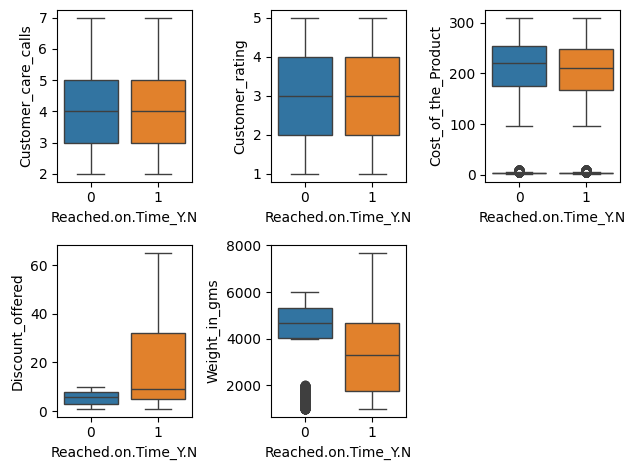

In [64]:
# Understanding correlation between dependent and independent variables
# Visually

# Numerical variables

fig = plt.figure()

# Customer_care_calls
plt.subplot(2, 3, 1)
sns.boxplot(data=data, x='Reached.on.Time_Y.N', y='Customer_care_calls', hue='Reached.on.Time_Y.N', legend=False)

# Customer_rating
plt.subplot(2, 3, 2)
sns.boxplot(data=data, x='Reached.on.Time_Y.N', y='Customer_rating', hue='Reached.on.Time_Y.N', legend=False)

# Cost_of_the_Product
plt.subplot(2, 3, 3)
sns.boxplot(data=data, x='Reached.on.Time_Y.N', y='Cost_of_the_Product', hue='Reached.on.Time_Y.N', legend=False)

# Prior_purchases
plt.subplot(2, 3, 3)
sns.boxplot(data=data, x='Reached.on.Time_Y.N', y='Prior_purchases', hue='Reached.on.Time_Y.N', legend=False)

# Discount_offered
plt.subplot(2, 3, 4)
sns.boxplot(data=data, x='Reached.on.Time_Y.N', y='Discount_offered', hue='Reached.on.Time_Y.N', legend=False)

# Weight_in_gms
plt.subplot(2, 3, 5)
sns.boxplot(data=data, x='Reached.on.Time_Y.N', y='Weight_in_gms', hue='Reached.on.Time_Y.N', legend=False)

plt.tight_layout()
plt.show()

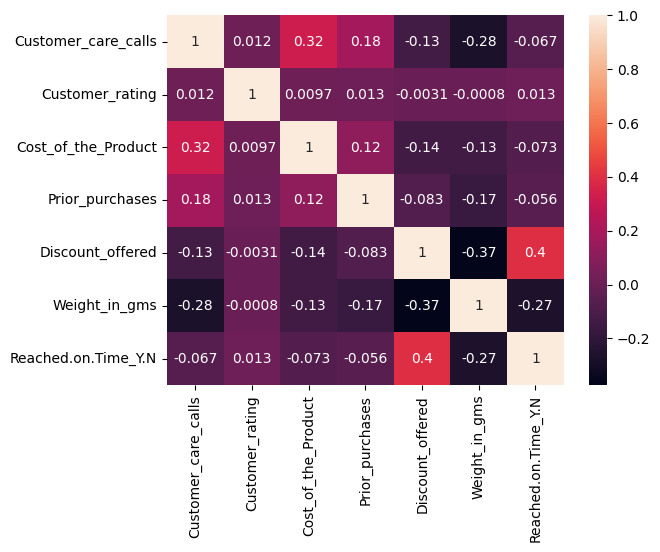

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
Customer_care_calls,1.000000,0.012209,0.320277,0.180771,-0.130750,-0.275409,-0.067126
Customer_rating,0.012209,1.000000,0.009747,0.013179,-0.003124,-0.000796,0.013119
Cost_of_the_Product,0.320277,0.009747,1.000000,0.122141,-0.136709,-0.133235,-0.073324
Prior_purchases,0.180771,0.013179,0.122141,1.000000,-0.082769,-0.167651,-0.055515
Discount_offered,-0.130750,-0.003124,-0.136709,-0.082769,1.000000,-0.373408,0.397108
Weight_in_gms,-0.275409,-0.000796,-0.133235,-0.167651,-0.373408,1.000000,-0.266318
Reached.on.Time_Y.N,-0.067126,0.013119,-0.073324,-0.055515,0.397108,-0.266318,1.000000


In [106]:
# Correlation of output with numerical columns
fig = plt.figure()
sns.heatmap(data=data[numerical_features + ['Reached.on.Time_Y.N']].corr(), annot=True)
plt.show()

(data[numerical_features + ['Reached.on.Time_Y.N']].corr())

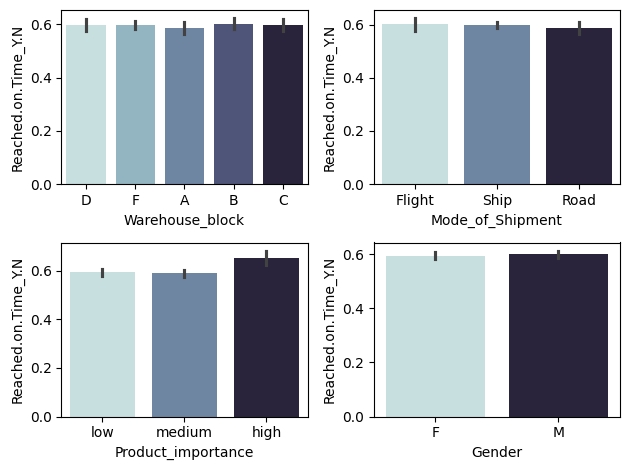

In [ ]:
# Categorical variables
# categorical_features = ['Warehouse_block', 'Mode_of_Shipment', 'Product_importance', 'Gender']

pallete = 'ch:start=.2,rot=-.3'
fig = plt.figure()
# Warehouse_block
plt.subplot(2, 2, 1)
sns.barplot(data=data, x='Warehouse_block', y='Reached.on.Time_Y.N', palette=pallete)

# Mode_of_Shipment
plt.subplot(2, 2, 2)
sns.barplot(data=data, x='Mode_of_Shipment', y='Reached.on.Time_Y.N', palette=pallete)

# Product_importance
plt.subplot(2, 2, 3)
sns.barplot(data=data, x='Product_importance', y='Reached.on.Time_Y.N', palette=pallete)

# Gender
plt.subplot(2, 2, 4)
sns.barplot(data=data, x='Gender', y='Reached.on.Time_Y.N', palette=pallete)

plt.tight_layout()
plt.show()

In [110]:
pd.get_dummies(data=data, columns=categorical_features, drop_first=False).replace({True: 1, False: 0})

,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N,Warehouse_block_A,Warehouse_block_B,Warehouse_block_C,Warehouse_block_D,Warehouse_block_F,Mode_of_Shipment_Flight,Mode_of_Shipment_Road,Mode_of_Shipment_Ship,Product_importance_high,Product_importance_low,Product_importance_medium,Gender_F,Gender_M
0,4,2,177.0,3,44,1233.0,1,0,0,0,1,0,1,0,0,0,1,0,1,0
1,4,5,216.0,2,59,3088.0,1,0,0,0,0,1,1,0,0,0,1,0,0,1
2,2,2,183.0,4,48,3374.0,1,1,0,0,0,0,1,0,0,0,1,0,0,1
3,3,3,176.0,4,10,1177.0,1,0,1,0,0,0,1,0,0,0,0,1,0,1
4,2,2,184.0,3,46,2484.0,1,0,0,1,0,0,1,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10994,4,1,252.0,5,1,1538.0,1,1,0,0,0,0,0,0,1,0,0,1,1,0
10995,4,1,232.0,5,6,1247.0,0,0,1,0,0,0,0,0,1,0,0,1,1,0
10996,5,4,242.0,5,4,1155.0,0,0,0,1,0,0,0,0,1,0,1,0,1,0
10997,5,2,223.0,6,2,1210.0,0,0,0,0,0,1,0,0,1,0,0,1,0,1


Reduce dimensions